# Puzzle-Solver mit Harris-Algorithmus und ORB

## Einleitung

In diesem Projekt haben wir uns dafür entschieden, den **Harris Corner Detection Algorithmus** zu verwenden, um die Position einzelner Puzzleteile im Gesamtbild zu erkennen. Ein wesentlicher Grund dafür ist seine **Rotationunabhängigkeit bei der Eckenerkennung**. Während viele klassische Detektionsmethoden bei Drehungen an Präzision verlieren, erkennt der Harris-Algorithmus lokale Intensitätsänderungen, die unabhängig von der Orientierung auftreten. So lassen sich stabile Eckpunkte auch bei rotierten Objekten erkennen – eine ideale Voraussetzung für das Erkennen von gedrehten Puzzleteilen.


## Eigene Implementierung des Corner-Detektors

Um die Funktionsweise besser zu verstehen, haben wir zunächst versucht, den Algorithmus **selbst zu implementieren**. Als Grundlage dafür diente der **Sobel-Filter**, mit dem man horizontale (`Iₓ`) und vertikale (`Iᵧ`) Intensitätsänderungen im Bild berechnen kann. Diese Ableitungen bilden die Grundlage für die sogenannte **Strukturmatrix** (auch Harris-Matrix genannt):

$$
M = \begin{bmatrix}
I_x^2 & I_x I_y \\
I_x I_y & I_y^2
\end{bmatrix}
$$

Diese Matrix beschreibt, wie stark sich die Intensität in einer kleinen Umgebung eines Pixels verändert – und in **welcher Richtung**. Durch Mittelung dieser Werte über ein kleines Fenster um jedes Pixel erkennt man, ob sich die Intensitäten:

- in keiner Richtung ändern (Fläche),
- nur in eine Richtung ändern (Kante),
- oder in mehrere Richtungen gleichzeitig ändern (Ecke).

Eine **Ecke** liegt genau dann vor, wenn sich die Intensität stark in **beide Richtungen** ändert. Mathematisch erkennt man das daran, dass **beide Eigenwerte der Matrix groß** sind.

Zur Entscheidung, ob ein Punkt eine Ecke ist, verwendet man die **Harris-Corner-Response-Funktion**:

$$
R = \text{det}(M) - k \cdot (\text{trace}(M))^2
$$

mit \( k \) als empirischer Parameter (typisch zwischen 0.04 und 0.1). Ein hoher Wert von \( R \) deutet auf eine Ecke hin.

---






In [101]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter
import cv2
from scipy.ndimage import rotate


In [102]:
# 1. Image Path for single puzzle piece and full puzzle piece
#TODO: Refactor to puzzle_piece and full_puzzle
image_path = Path("..") / "data" / "poster_puzzle_edited" / "wonka_004_edited.png"
image_path_full = Path("..") / "data" / "poster_puzzle_edited" / "wonka_full_edited.png"

In [103]:
# ----------------------------------------
# Funktion: Graustufenbild laden
# ----------------------------------------
def load_grayscale_image(path):
    """
    Lädt ein Bild vom gegebenen Pfad und wandelt es in ein 2D-Graustufen-Array um (float32).
    
    Warum?
    - Harris Corner Detection benötigt ein einzelnes Intensitätsbild.
    - float32 für numerisch stabile Berechnungen.
    """
    img = Image.open(path).convert("L")  # "L" = grayscale mode
    return np.array(img, dtype=np.float32)

# ----------------------------------------
# Funktion: Harris Corner Detection
# ----------------------------------------
def harris_corner_detection(image, k=0.05, window_size=5, threshold=0):
    """
    Führt Harris-Corner-Detection auf einem gegebenen Graustufenbild aus.

    Parameter:
    - k: Empfindlichkeitsfaktor für Ecken (typisch 0.04–0.06)
    - window_size: Fenstergröße für lokale Summen (z. B. 3x3 oder 5x5)
    - threshold: Mindest-R-Wert (meist 0, Filterung später sinnvoller)

    Rückgabe:
    - corners: Binärmaske der Ecken (nur Score > threshold)
    - R: vollständige Corner-Response Matrix
    """
    # Sobel-Filter zur Gradientenberechnung
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]], dtype=np.float32)

    # Bildgradienten berechnen
    Ix = convolve2d(image, sobel_x, mode='same', boundary='symm')
    Iy = convolve2d(image, sobel_y, mode='same', boundary='symm')

    # Gradientprodukte
    Ix2 = Ix ** 2
    Iy2 = Iy ** 2
    Ixy = Ix * Iy

    # Lokale Summierung der Produkte über Fenster
    w = np.ones((window_size, window_size))
    Sx2 = convolve2d(Ix2, w, mode='same', boundary='symm')
    Sy2 = convolve2d(Iy2, w, mode='same', boundary='symm')
    Sxy = convolve2d(Ixy, w, mode='same', boundary='symm')

    # Harris-Matrix: R = det(M) - k * (trace(M))²
    detM = Sx2 * Sy2 - Sxy ** 2
    traceM = Sx2 + Sy2
    R = detM - k * (traceM ** 2)

    # Nur Werte über Schwelle behalten (optional – meist threshold = 0)
    corners = (R > threshold) * R
    return corners, R

# ----------------------------------------
# Funktion: Stärkste Ecken extrahieren
# ----------------------------------------
def filter_strongest_corners(corner_response, threshold_ratio=0.03, max_corners=200):
    """
    Filtert die stärksten Ecken basierend auf ihrem Harris-Score.

    Parameter:
    - corner_response: Corner-Response-Matrix (R-Werte)
    - threshold_ratio: Prozentwert von max(R), um schwache Ecken rauszufiltern
    - max_corners: Anzahl der besten Ecken, die zurückgegeben werden

    Rückgabe:
    - x, y: Koordinaten der stärksten Ecken
    """
    max_r = np.max(corner_response)
    threshold = max_r * threshold_ratio

    y, x = np.where(corner_response > threshold)
    scores = corner_response[y, x]

    sorted_indices = np.argsort(-scores)
    selected_indices = sorted_indices[:max_corners]

    return x[selected_indices], y[selected_indices]


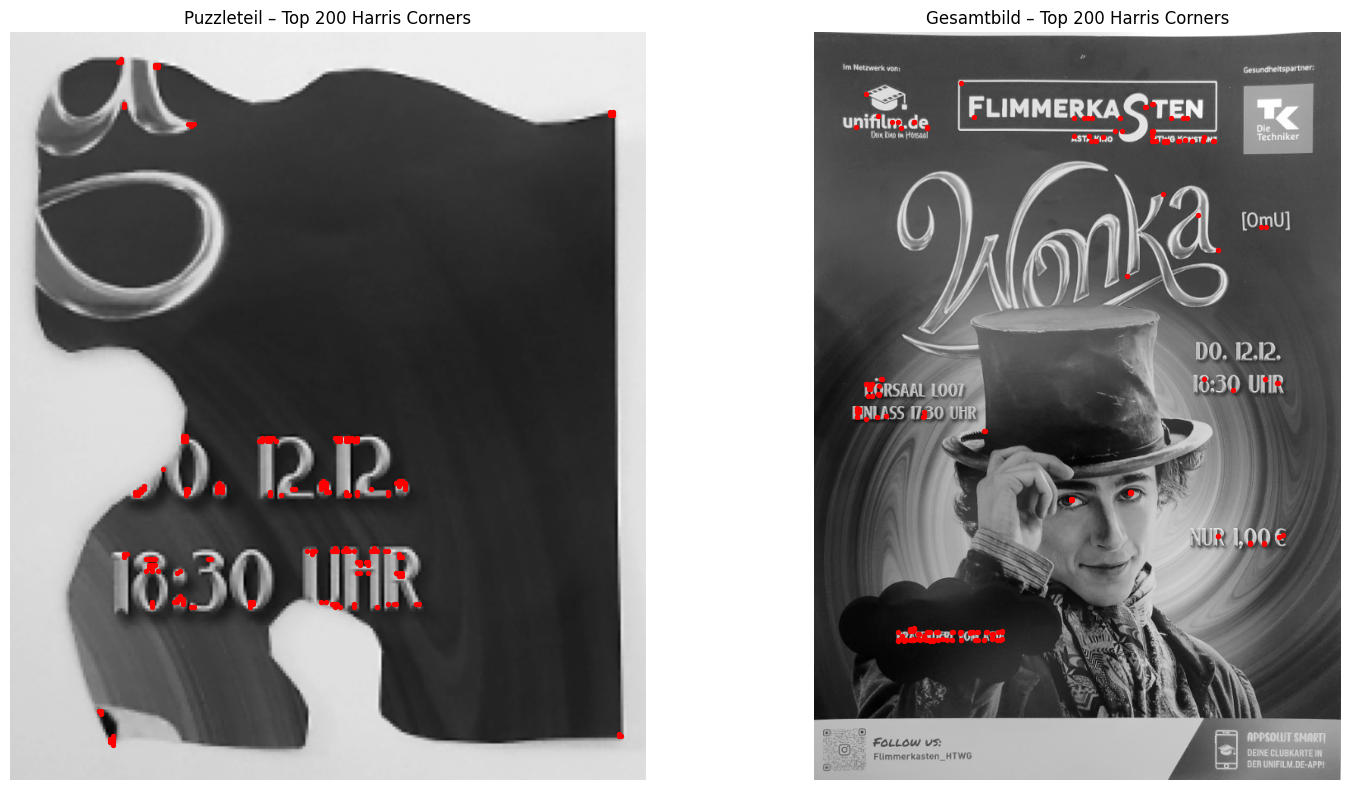

In [104]:
# Harris auf Einzelbild
image = load_grayscale_image(image_path)
corners, response = harris_corner_detection(image, k=0.08, window_size=3, threshold=0)
x_strong, y_strong = filter_strongest_corners(response, threshold_ratio=0.025, max_corners=200)

# Harris auf Gesamtbild
image_full = load_grayscale_image(image_path_full)
corners_full, response_full = harris_corner_detection(image_full, k=0.08, window_size=3, threshold=0)
x_strong_full, y_strong_full = filter_strongest_corners(response_full, threshold_ratio=0.025, max_corners=200)

# Gemeinsame Visualisierung
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Bild 1: Einzelbild
axs[0].imshow(image, cmap='gray')
axs[0].scatter(x_strong, y_strong, c='red', s=8)
axs[0].set_title("Puzzleteil – Top 200 Harris Corners")
axs[0].axis('off')

# Bild 2: Gesamtbild
axs[1].imshow(image_full, cmap='gray')
axs[1].scatter(x_strong_full, y_strong_full, c='red', s=8)
axs[1].set_title("Gesamtbild – Top 200 Harris Corners")
axs[1].axis('off')

plt.tight_layout()
plt.show()


### Was sind Deskriptoren und warum brauchen wir sie?

Das Erkennen von Ecken allein reicht noch nicht aus, um herauszufinden, **welche Ecke zu welcher passt**. Dafür brauchen wir sogenannte **Deskriptoren**.

Ein **Deskriptor** ist eine kompakte Beschreibung der Umgebung rund um eine erkannte Ecke – z. B. anhand der Intensitätsverteilung, Gradientenrichtung oder lokaler Muster. Diese Deskriptoren erlauben es, **vergleichbare Merkmale** in zwei unterschiedlichen Bildern zu finden.

Durch Vergleich der Deskriptoren können wir sagen: *Diese beiden Ecken sehen ähnlich aus – wahrscheinlich gehören sie zusammen.*

---

### Eigene Deskriptor-Implementierung

Wir haben versucht, eigene Deskriptoren zu erzeugen, indem wir um jeden erkannten Eckpunkt ein kleines lokales Fenster (z. B. 11×11 Pixel) extrahiert und als Merkmal verwendet habe – entweder direkt als Intensitätswerte oder über Ableitungen (Gradienten).

Diese Deskriptoren wurden dann mit denen aus einem größeren Bild verglichen, um **Matches** zu finden – also passende Eckpaare. Leider war diese Methode **nicht robust genug**. Schon kleine Abweichungen in Rotation, Helligkeit oder Skalierung führten dazu, dass Deskriptoren nicht mehr übereinstimmten.

Das hatte zur Folge, dass beim Matching zwischen Puzzleteil und Gesamtbild viele **False Positives** auftraten – also scheinbar passende Ecken, die tatsächlich nicht zueinandergehörten. Besonders in sehr ähnlichen Bildbereichen konnte man die Ecken nicht mehr sicher zuordnen.

In [105]:

def extract_normalized_patches(image, keypoints_x, keypoints_y, patch_size=11):
    """
    Extrahiert normalisierte quadratische Patches um jeden Keypoint aus einem Graustufenbild.

    Parameter:
    - image: 2D-Graustufenbild (z. B. vorverarbeitetes Puzzlebild)
    - keypoints_x: X-Koordinaten der Keypoints
    - keypoints_y: Y-Koordinaten der Keypoints
    - patch_size: Breite/Höhe des quadratischen Patches (ungerade Zahl, z. B. 11)

    Rückgabe:
    - descriptors: Liste von 1D-Vektoren mit normalisierten Pixelwerten
    - valid_x: X-Koordinaten der tatsächlich verwendeten Keypoints (nur die mit vollem Patch)
    - valid_y: Y-Koordinaten der tatsächlich verwendeten Keypoints
    """

    assert patch_size % 2 == 1, "patch_size muss ungerade sein (z. B. 11)."
    half = patch_size // 2

    descriptors = []
    valid_x = []
    valid_y = []

    for x, y in zip(keypoints_x, keypoints_y):
        # Stelle sicher, dass das Patch innerhalb des Bildes liegt
        if (x - half >= 0 and x + half < image.shape[1] and
            y - half >= 0 and y + half < image.shape[0]):

            patch = image[y - half:y + half + 1, x - half:x + half + 1].astype(np.float32)

            # Normalisiere Patch (zentrieren + skalieren)
            mean = np.mean(patch)
            std = np.std(patch)
            if std > 1e-5:
                patch = (patch - mean) / std  # Z-Score Normalisierung
            else:
                patch = patch - mean  # nur zentrieren, falls std ≈ 0

            descriptors.append(patch.flatten())  # als 1D-Vektor
            valid_x.append(x)
            valid_y.append(y)

    return np.array(descriptors), np.array(valid_x), np.array(valid_y)

def match_descriptors(desc1, desc2, threshold=0.6):
    """
    Vergleicht zwei Mengen von Deskriptoren per L2-Distanz (Brute Force).
    Nimmt nur Matches auf, bei denen der beste Match deutlich besser ist als der zweitbeste (Ratio-Test).

    Args:
        desc1 (np.ndarray): Deskriptoren vom Puzzleteil, Form (N, D)
        desc2 (np.ndarray): Deskriptoren vom Gesamtbild, Form (M, D)
        threshold (float): Schwellenwert für den Ratio-Test

    Returns:
        matches (List[Tuple[int, int]]): Liste der Indizes (i, j) der gematchten Deskriptoren
    """
    matches = []
    for i, d1 in enumerate(desc1):
        dists = np.linalg.norm(desc2 - d1, axis=1)
        if len(dists) < 2:
            continue
        sorted_idx = np.argsort(dists)
        best, second_best = dists[sorted_idx[0]], dists[sorted_idx[1]]
        if best / second_best < threshold:
            matches.append((i, sorted_idx[0]))
    return matches


def plot_matches(img1, kp1, img2, kp2, matches, max_lines=50):
    """
    Zeigt gematchte Keypoints zwischen zwei Bildern mit Linien.

    Args:
        img1, img2: Bilder als Graustufen (2D np.ndarray)
        kp1, kp2: Keypoints als Listen von (x, y)-Tupeln
        matches: Liste von (i, j)-Tupeln (Indexpaare)
    """
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    vis = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8)
    vis[:h1, :w1] = img1
    vis[:h2, w1:] = img2

    plt.figure(figsize=(12, 6))
    plt.imshow(vis, cmap='gray')
    for (i, j) in matches[:max_lines]:
        x1, y1 = kp1[i]
        x2, y2 = kp2[j]
        plt.plot([x1, x2 + w1], [y1, y2], 'cyan', linewidth=0.7)
        plt.plot(x1, y1, 'ro', markersize=3)
        plt.plot(x2 + w1, y2, 'go', markersize=3)
    plt.axis('off')
    plt.title(f"Top {len(matches[:max_lines])} Matches")
    plt.tight_layout()
    plt.show()



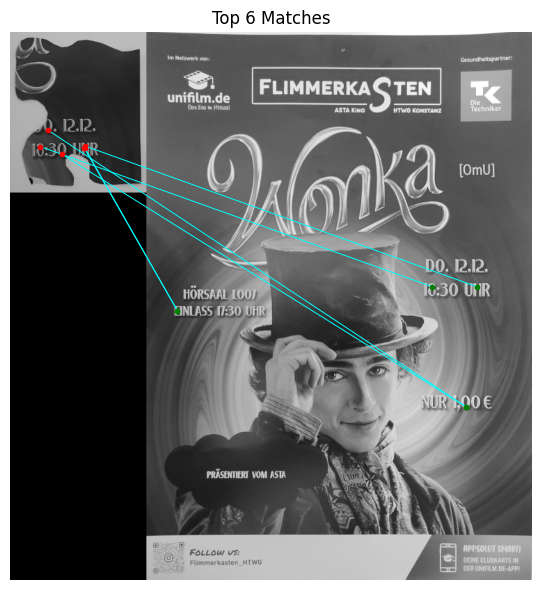

In [106]:
# 1. Generate descriptors from image + keypoints
descriptors, x_valid, y_valid = extract_normalized_patches(
    image=image, 
    keypoints_x=x_strong, 
    keypoints_y=y_strong, 
    patch_size=11
)

# 1. Generate descriptors from image + keypoints 
descriptors_full, x_valid_full, y_valid_full = extract_normalized_patches(
    image=image_full, 
    keypoints_x=x_strong_full, 
    keypoints_y=y_strong_full, 
    patch_size=11
)

# Matches berechnen
matches = match_descriptors(descriptors, descriptors_full, threshold=0.6)

keypoints1= list(zip(x_strong, y_strong))
keypoints2 = list(zip(x_strong_full, y_strong_full))

# Matches visualisieren
plot_matches(img1=image, kp1=keypoints1, img2=image_full, kp2=keypoints2, matches=matches)


## Lösung: Window-Sliding zur Einschränkung der Matches

Um dieses Problem zu beheben, habe ich einen **Window-Sliding-Mechanismus** eingeführt. Dabei wird das große Puzzlebild in kleinere Fenster unterteilt. Die Fenstergrössen ergeben sich aus der angenommenen Anzahl an Puzzleteilen in X- und Y-Richtung. Für jedes dieser Fenster werden die Deskriptoren mit denen des Puzzleteils verglichen.

Anschliessend wird **das Fenster mit den meisten gültigen Matches** ausgewählt. So lassen sich die False Positives deutlich reduzieren, weil wir nur lokal vergleichen und nicht mehr global im ganzen Bild.

Wichtig zu beachten ist dabei:
- Die Anzahl der Puzzleteile in X und Y muss bekannt oder geschätzt werden.
- Die Grössenverhältnisse der Bilder müssen grob übereinstimmen.

Dies ist leider ein **Nachteil** der Methode: Bei stark unterschiedlichen Grössenverhältnissen oder ungleichmässigen Puzzleteilgrössen kann die Lokalisierung fehlschlagen.

In [107]:
def sliding_window_matching_custom(
    image_full,
    image_patch,
    patch_kps,
    patch_desc,
    extract_patch_descriptors_fn,
    num_windows_x=2,
    num_windows_y=2,
    patch_size=11,
    match_threshold=0.6
):
    """
    Führt Sliding-Window-Matching durch, indem das große Bild in Fenster aufgeteilt wird.
    Jeder Bereich wird mit den Keypoints/Deskriptoren des Puzzleteils verglichen.

    Args:
        image_full: das große Bild (2D Graustufenbild)
        image_patch: das kleine Puzzleteilbild
        patch_kps: Keypoints im Puzzleteil [(x, y), ...]
        patch_desc: Deskriptoren im Puzzleteil, NxD
        extract_patch_descriptors_fn: Funktion zum Extrahieren der Deskriptoren
        num_windows_x: Anzahl Fenster horizontal
        num_windows_y: Anzahl Fenster vertikal
        patch_size: für Deskriptorenextraktion
        match_threshold: Ratio-Test Schwelle

    Returns:
        best_matches: Liste der besten Matches
        best_region: (x_start, y_start, x_end, y_end) im Gesamtbild
        matched_kp_full: Keypoints im Gesamtbild, passend zu best_matches
    """
    h_full, w_full = image_full.shape
    win_w = w_full // num_windows_x
    win_h = h_full // num_windows_y

    best_matches = []
    best_region = None
    matched_kp_full = []


    for i in range(num_windows_x):
        for j in range(num_windows_y):
            x_start = i * win_w
            y_start = j * win_h
            x_end = x_start + win_w
            y_end = y_start + win_h

            window = image_full[y_start:y_end, x_start:x_end]

            # Lokale Ecken berechnen
            corners_win, response_win = harris_corner_detection(window, k=0.08, window_size=3)
            x_win, y_win = filter_strongest_corners(response_win, threshold_ratio=0.03, max_corners=200)

            # Deskriptoren im Fenster extrahieren
            desc_win, x_valid, y_valid = extract_patch_descriptors_fn(window, x_win, y_win, patch_size=patch_size)

            if len(desc_win) == 0:
                continue

            # Deskriptoren matchen
            matches = match_descriptors(patch_desc, desc_win, threshold=match_threshold)

            # Prüfen, ob das beste Ergebnis ist
            if len(matches) > len(best_matches):
                best_matches = matches
                best_region = (x_start, y_start, x_end, y_end)
                #matched_kp_full = [(x_valid[j] + x_start, y_valid[j] + y_start) for (_, j) in matches]
                kp_full_all = list(zip(x_valid + x_start, y_valid + y_start))


    #return best_matches, best_region, matched_kp_full
    return best_matches, best_region, kp_full_all


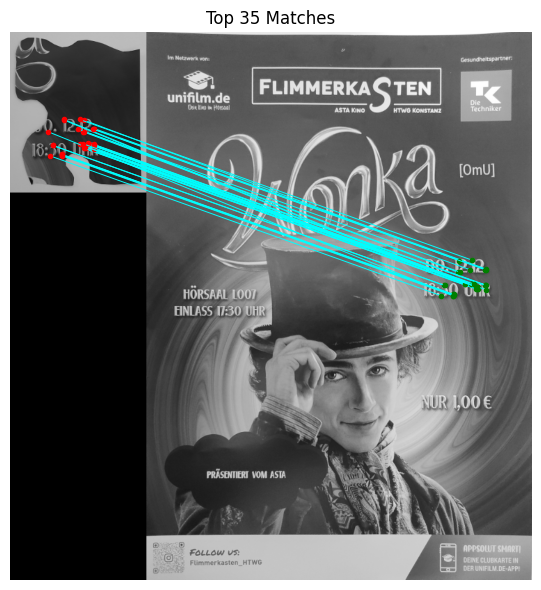

In [108]:


# Puzzleteil Deskriptoren erzeugen
descriptors, x_valid, y_valid = extract_normalized_patches(image, x_strong, y_strong)
patch_kps = list(zip(x_valid, y_valid))
# Sliding Window Matching
matches, region, kp_matched = sliding_window_matching_custom(
    image_full=image_full,
    image_patch=image,
    patch_kps=patch_kps,
    patch_desc=descriptors,
    extract_patch_descriptors_fn=extract_normalized_patches,
    num_windows_x=4,
    num_windows_y=4,
    patch_size=11,
    match_threshold=0.6
)

# Visualisierung
plot_matches(image, patch_kps, image_full, kp_matched, matches)


## Test auf Rotationsinvarianz

In einem weiteren Schritt habe ich geprüft, ob der Harris-Algorithmus in Kombination mit den **selbst erstellten Deskriptoren** rotationsrobust ist. Leider zeigte sich, dass die Erkennung bei gedrehten Puzzleteilen **nicht mehr zuverlässig** funktionierte. Der Grund liegt darin, dass die **selbstgebauten Deskriptoren nicht rotationsinvariant** sind – sie verändern sich bei jeder Drehung des Bildausschnitts und führen somit zu anderen (falschen) Matches.

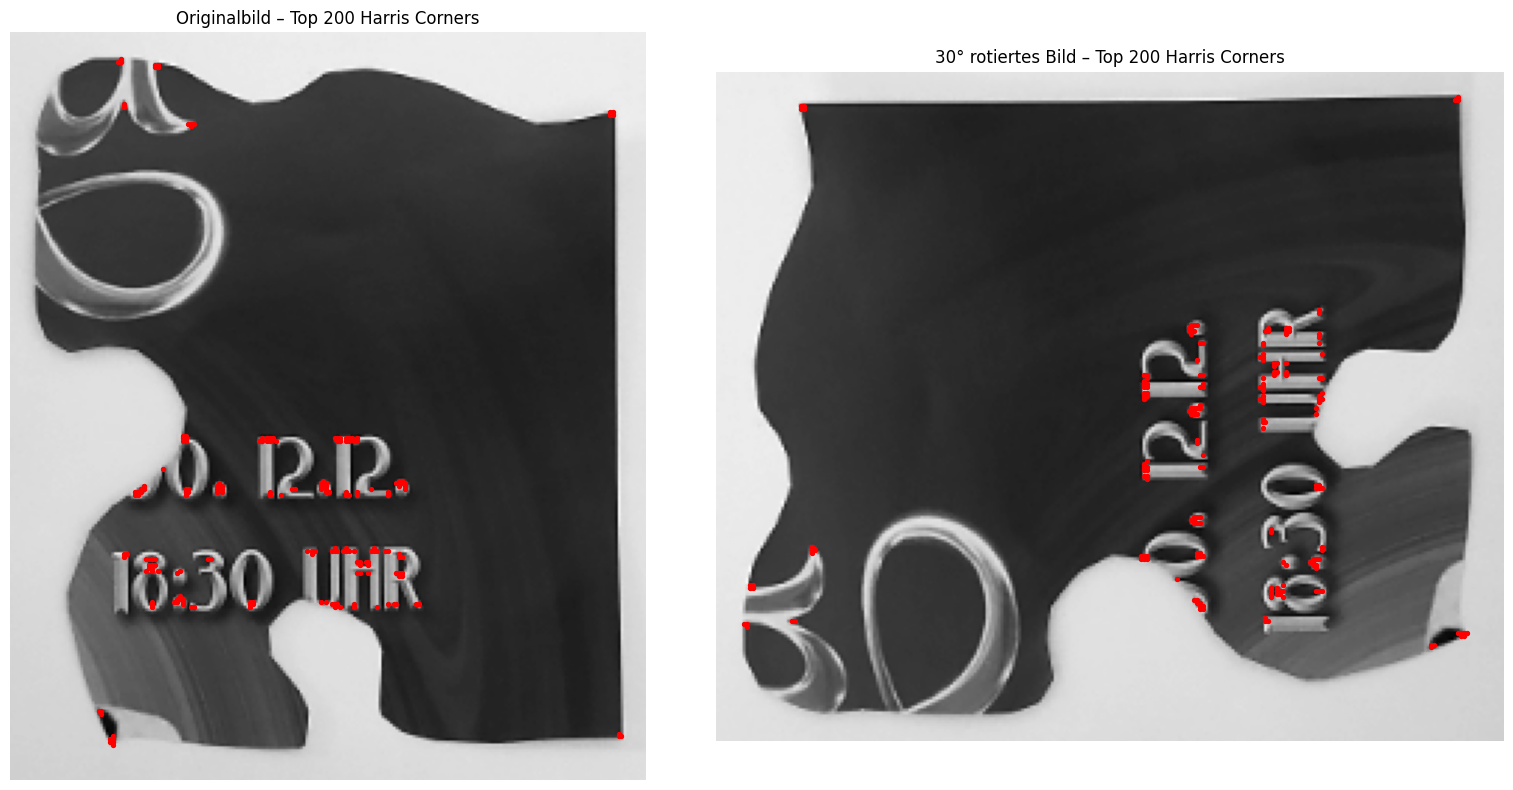

In [ ]:
# Originalbild vorbereiten
image = load_grayscale_image(image_path)
corners_orig, response_orig = harris_corner_detection(image, k=0.08, window_size=3, threshold=0)
x_strong_orig, y_strong_orig = filter_strongest_corners(response_orig, threshold_ratio=0.025, max_corners=200)

# Rotiertes Bild vorbereiten
image_rotated = load_grayscale_image(image_path)
image_rotated = rotate(image_rotated, 90, reshape=True, mode='constant', cval=0)
corners, response = harris_corner_detection(image_rotated, k=0.08, window_size=3, threshold=0)
x_strong, y_strong = filter_strongest_corners(response, threshold_ratio=0.025, max_corners=200)

# Gemeinsame Visualisierung
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Originalbild
axs[0].imshow(image, cmap='gray')
axs[0].scatter(x_strong_orig, y_strong_orig, c='red', s=8)
axs[0].set_title("Originalbild – Top 200 Harris Corners")
axs[0].axis('off')

# Rotiertes Bild
axs[1].imshow(image_rotated, cmap='gray')
axs[1].scatter(x_strong, y_strong, c='red', s=8)
axs[1].set_title("90° rotiertes Bild – Top 200 Harris Corners")
axs[1].axis('off')

plt.tight_layout()
plt.show()


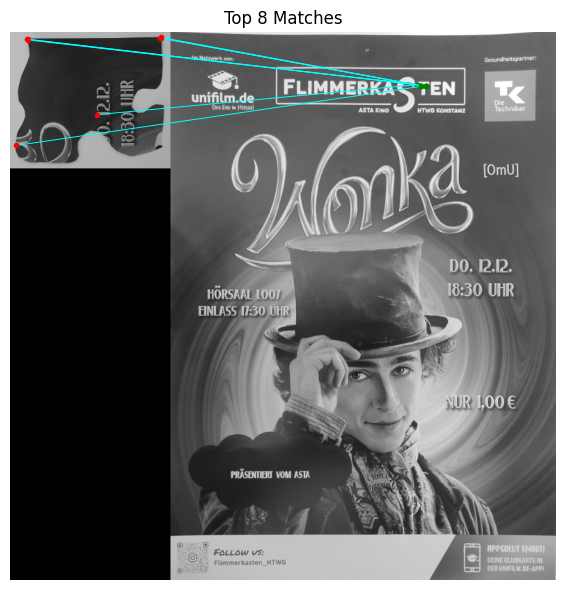

In [112]:


# Puzzleteil Deskriptoren erzeugen
descriptors, x_valid, y_valid = extract_normalized_patches(image_rotated, x_strong, y_strong)
patch_kps = list(zip(x_valid, y_valid))
# Sliding Window Matching
matches, region, kp_matched = sliding_window_matching_custom(
    image_full=image_full,
    image_patch=image_rotated,
    patch_kps=patch_kps,
    patch_desc=descriptors,
    extract_patch_descriptors_fn=extract_normalized_patches,
    num_windows_x=4,
    num_windows_y=4,
    patch_size=11,
    match_threshold=0.6
)

# Visualisierung
plot_matches(image_rotated, patch_kps, image_full, kp_matched, matches)


## Wechsel zur ORB-Bibliothek

Um das Problem der Deskriptoren zu lösen, habe ich auf die **ORB-Bibliothek** zurückgegriffen. ORB steht für *Oriented FAST and Rotated BRIEF*. Diese Methode kombiniert eine schnelle Eckpunktdetektion mit **rotationsinvarianten Deskriptoren**, die sich hervorragend für Feature-Matching eignen.

Mit ORB habe ich sowohl die Eckpunkte als auch die Deskriptoren bestimmen lassen – allerdings traten auch hier ohne Einschränkung auf das Suchfenster **viele False Positives** auf. Die Lösung war erneut die Kombination mit **Window Sliding**, wie zuvor bei der selbstgebauten Methode.


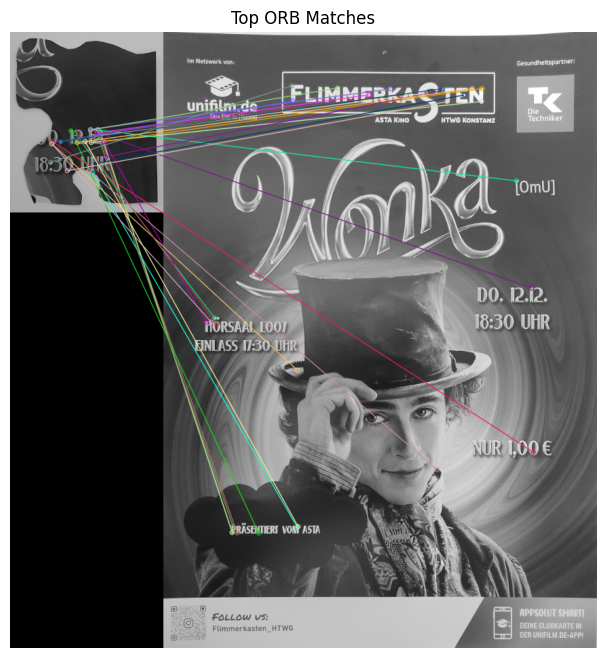

In [113]:

# ORB Keypoints und Deskriptoren berechnen
image_uint8 = image.astype(np.uint8)
image_full_uint8 = image_full.astype(np.uint8)
orb = cv2.ORB_create(nfeatures=200)
keyPoints_piece, descriptor_piece = orb.detectAndCompute(image_uint8, None)
keyPoints_full, descriptor_full = orb.detectAndCompute(image_full_uint8, None)

# Deskriptoren matchen
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(descriptor_piece, descriptor_full)

# Matches nach Distanz sortieren
matches = sorted(matches, key=lambda x: x.distance)

# Top-Matches visualisieren
match_img = cv2.drawMatches(
    image_uint8, keyPoints_piece,
    image_full_uint8, keyPoints_full,
    matches[:30],  # zeige die besten 30
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

# Anzeige mit matplotlib
plt.figure(figsize=(15, 8))
plt.imshow(match_img)
plt.title("Top ORB Matches")
plt.axis("off")
plt.show()


## Ergebnis mit ORB + Window Sliding

Mit dem ORB-Ansatz und der Fenster-basierten Suche funktionierte die Lokalisierung der Puzzleteile **sehr robust** – auch bei Drehungen um 90°, 180° oder beliebigen Winkeln. Die Kombination erlaubt eine **exakte Lokalisierung unabhängig von der Orientierung** des Puzzleteils im Bild.

In [121]:

# ----------------------------------------
# Funktion: ORB-Deskriptoren extrahieren
# ----------------------------------------
def extract_orb_keypoints_and_descriptors(image_uint8):
    orb = cv2.ORB_create(nfeatures=500)
    keypoints, descriptors = orb.detectAndCompute(image_uint8, None)
    return keypoints, descriptors

# ----------------------------------------
# Funktion: Sliding-Window-ORB-Matching
# ----------------------------------------
def sliding_window_orb_matching(image_full_uint8, image_piece_uint8, num_windows_x=3, num_windows_y=3):
    kp_piece, desc_piece = extract_orb_keypoints_and_descriptors(image_piece_uint8)

    h_full, w_full = image_full_uint8.shape
    window_width = w_full // num_windows_x
    window_height = h_full // num_windows_y

    best_matches = []
    best_region_coords = None
    best_kp_full = []

    for i in range(num_windows_x):
        for j in range(num_windows_y):
            x_start = i * window_width
            y_start = j * window_height
            x_end = x_start + window_width
            y_end = y_start + window_height

            window = image_full_uint8[y_start:y_end, x_start:x_end]
            kp_window, desc_window = extract_orb_keypoints_and_descriptors(window)

            if desc_window is None or desc_piece is None:
                continue

            bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
            matches = bf.match(desc_piece, desc_window)

            if len(matches) > len(best_matches):
                best_matches = matches
                best_region_coords = (x_start, y_start, x_end, y_end)
                best_kp_full = [(int(kp.pt[0] + x_start), int(kp.pt[1] + y_start)) for kp in kp_window]

    return best_matches, best_region_coords, best_kp_full, kp_piece

# ----------------------------------------
# Funktion: Matches visualisieren
# ----------------------------------------
def plot_orb_window_matches(image_piece_uint8, image_full_uint8, kp_piece, kp_full_coords, matches, max_matches=30):
    # Bildhöhen angleichen durch Padding
    height_piece, width_piece = image_piece_uint8.shape
    height_full, width_full = image_full_uint8.shape

    if height_piece != height_full:
        if height_piece < height_full:
            pad_height = height_full - height_piece
            image_piece_uint8 = np.pad(image_piece_uint8, ((0, pad_height), (0, 0)), mode='constant', constant_values=0)
        else:
            pad_height = height_piece - height_full
            image_full_uint8 = np.pad(image_full_uint8, ((0, pad_height), (0, 0)), mode='constant', constant_values=0)

    img_matches = np.hstack((image_piece_uint8, image_full_uint8))


    plt.figure(figsize=(15, 6))
    plt.imshow(img_matches, cmap='gray')

    for m in matches[:max_matches]:
        x1, y1 = kp_piece[m.queryIdx].pt
        x2, y2 = kp_full_coords[m.trainIdx]
        x2 += image_piece_uint8.shape[1]

        plt.plot([x1, x2], [y1, y2], 'c-', linewidth=0.7)
        plt.plot(x1, y1, 'ro', markersize=3)
        plt.plot(x2, y2, 'go', markersize=3)

    plt.title(f"Top {max_matches} ORB-Matches im besten Fenster")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


0° Rotation


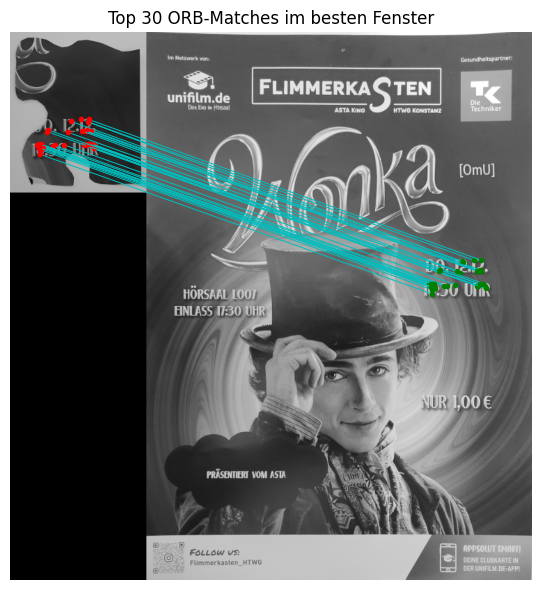

30° Rotation


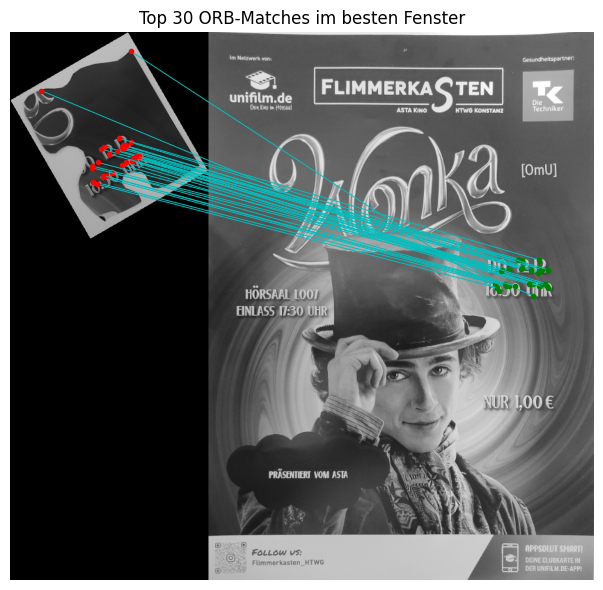

90° Rotation


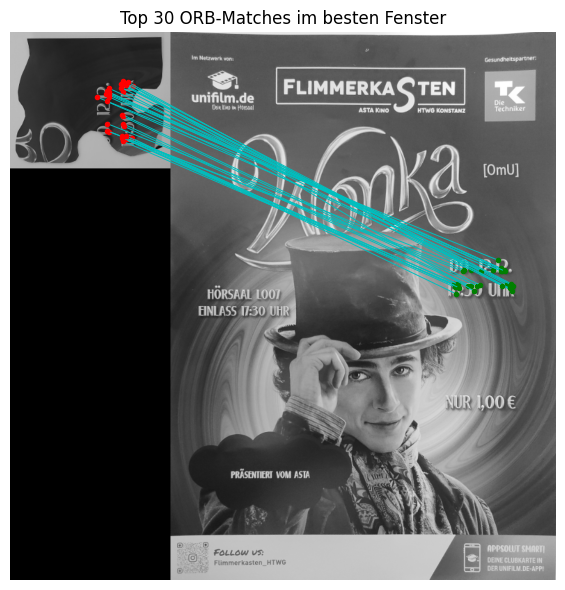

In [122]:
# Drei Versionen des Puzzleteils vorbereiten
image_piece_0 = image.astype(np.uint8)
image_rotated_30 = rotate(image, 30, reshape=True, mode='constant', cval=0).astype(np.uint8)
image_rotated_90 = rotate(image, 90, reshape=True, mode='constant', cval=0).astype(np.uint8)

# Referenzbild
image_full_0 = image_full.astype(np.uint8)

# Liste für Durchläufe
rotated_versions = [
    ("0° Rotation", image_piece_0),
    ("30° Rotation", image_rotated_30),
    ("90° Rotation", image_rotated_90)
]

# Plot nacheinander untereinander
for title, img_piece in rotated_versions:
    matches, coords, kp_full, kp_piece = sliding_window_orb_matching(
        image_full_0,
        img_piece,
        num_windows_x=3,
        num_windows_y=3
    )

    print(title)
    plot_orb_window_matches(
        img_piece,
        image_full_0,
        kp_piece,
        kp_full,
        matches,
        max_matches=30
    )





## Warum sind ORB-Deskriptoren rotationsrobust?

Der Schlüssel liegt in der Art, wie ORB seine Deskriptoren berechnet:

1. **Keypoint-Orientierung**  
   Für jeden erkannten Eckpunkt wird eine Orientierung berechnet, basierend auf der Intensitätsverteilung in der Umgebung. Dadurch wird der Deskriptor **relativ zu dieser lokalen Orientierung** erzeugt.

2. **BRIEF mit Rotation**  
   ORB basiert auf BRIEF-Deskriptoren, welche eigentlich nicht rotationsrobust sind. In ORB wird der BRIEF-Deskriptor aber **um die ermittelte Orientierung des Keypoints rotiert**, bevor er gespeichert wird. So bleibt der Deskriptor **bei Drehung des Bildes gleich**, weil er mitrotiert wird – daher ist er robust gegenüber Rotation.

Diese Technik macht ORB ideal für Aufgaben wie unsere Puzzle-Zuordnung, bei denen die Orientierung der Teile unbekannt ist.

## Fazit

Zusammenfassend zeigt sich:

- Der Harris-Algorithmus ist ein sehr präziser Corner-Detektor.
- Selbst entwickelte Deskriptoren sind ohne zusätzliche Orientierung nicht robust genug.
- ORB bietet eine kompakte, performante Lösung für Deskriptoren mit Rotationstoleranz.
- **Window Sliding** ist ein effektiver Trick zur Lokalisierung im Gesamtbild.
- Für reale Anwendungen wie Puzzles oder Objektzuordnung bietet die Kombination aus **ORB + Sliding Window** eine praktikable und zuverlässige Lösung.
